## 6.3 神经网络参数优化 - 指数移动加权平均介绍


#### 1. 为什么需要改进梯度下降
在前面的学习中，我们已经知道神经网络训练的核心是：

![Pasted Graphic.png](<attachment:Pasted Graphic.png>)

这就是 梯度下降（Gradient Descent）。

但是在实际训练神经网络时，普通梯度下降会遇到很多问题。

![B$ 1R 19.png](<attachment:B$ 1R 19.png>)
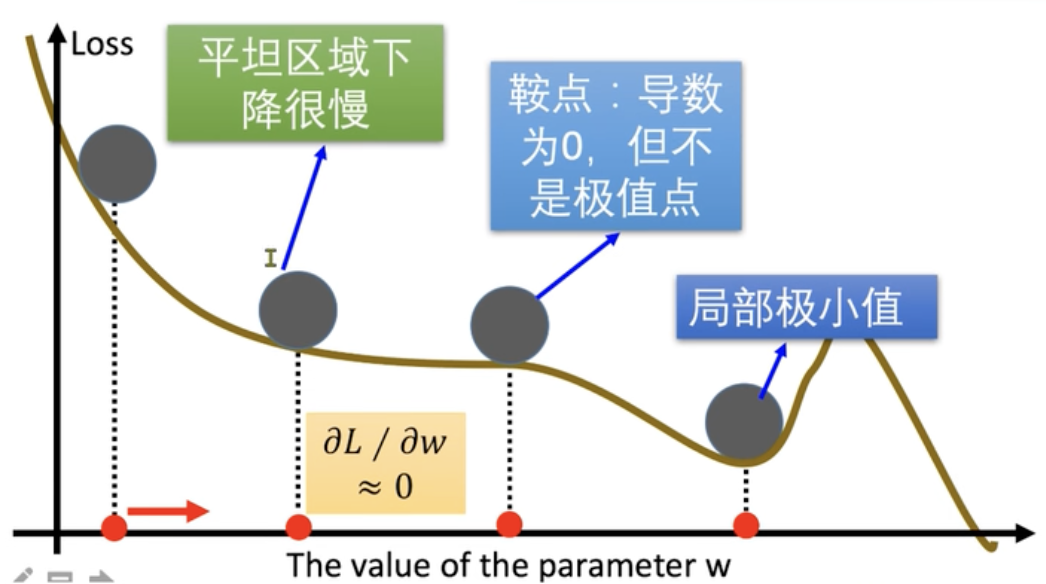
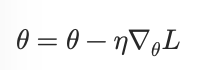

##### 1.1 平坦区域（Plateau）
在一些区域中，损失函数的曲面非常平缓：

在这种情况下：
* 梯度非常小

导致：
* 参数更新非常慢
* 训练可能会 长时间停留在平坦区域。

##### 1.2 鞍点（Saddle Point）
在高维空间中，鞍点非常常见。

特点：
* 梯度 = 0
* 但不是最小值

因此：
* 梯度下降可能停在鞍点附近
* 训练会 卡住。

##### 1.3 梯度震荡（Oscillation）
在一些损失函数中，曲面可能非常狭长

如果使用普通梯度下降：
* 参数更新会在两侧来回震荡

表现为：
* ↘ ↗ ↘ ↗ ↘ ↗

导致：
* 收敛速度很慢

##### 1.4 局部极小值（Local Minimum）
损失函数可能有很多局部最低点：

梯度下降可能会：
* 陷入局部最优
* 而不是找到 全局最优。

#### 2. 优化算法的核心思路
为了改进梯度下降，研究者提出了很多优化算法，例如：
* Momentum
* AdaGrad
* RMSProp
* Adam

这些算法背后的核心思想其实只有两个：

##### 2.1 利用历史梯度信息
普通梯度下降只看：
* 当前梯度

但优化算法会利用：
* 过去多个梯度
* 从而获得更稳定的更新方向。

##### 2.2 自适应学习率
普通梯度下降：
* 所有参数使用同一个学习率

但优化算法会：
* 为不同参数使用不同学习率
* 从而提高训练效率。

#### 3. 指数移动加权平均（EMA）
很多优化算法的底层思想其实都来自一个数学工具：

`指数移动加权平均（Exponential Moving Average，EMA）`

##### 3.1 什么是移动平均
假设我们有一组数据：

`10, 12, 13, 15, 20`

普通平均：

![10 + 12 + 13 + 15 + 20.png](<attachment:10 + 12 + 13 + 15 + 20.png>)

但是这种平均：
* 所有数据权重相同

而在很多场景中，我们希望：
* 最近的数据更重要
* 这就是 移动平均（Moving Average） 的思想。
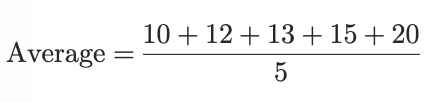

##### 3.2 指数移动加权平均公式
EMA 的公式为：

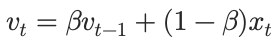

其中：

![Pasted Graphic 4.png](<attachment:Pasted Graphic 4.png>)

通常：
```
β ≈ 0.9
β ≈ 0.99
β ≈ 0.999
```
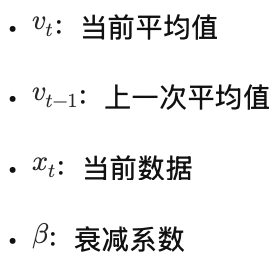

##### 3.3 公式的直观含义
这个公式表示：
```
新的平均值
=
过去平均值的一部分
+
当前数据的一部分
```

例如：

`β = 0.9`

那么：

`vt = 0.9 vt-1 + 0.1 xt`

意味着：
* 过去平均值占90%
* 当前数据占10%

##### 3.4 示例：
假设：

`β = 0.9`

初始化：
`v₀ = 0`

**第1个数据（10）**
```
v₁ = 0.9 × 0 + 0.1 × 10
    = 1
```
**第2个数据（12）**
```
v₂ = 0.9 × 1 + 0.1 × 12
    = 0.9 + 1.2
    = 2.1
```
**第3个数据（13）**
```
v₃ = 0.9 × 2.1 + 0.1 × 13
    = 1.89 + 1.3
    = 3.19
```
**第4个数据（15）**
```
v₄ = 0.9 × 3.19 + 0.1 × 15
    = 2.871 + 1.5
    = 4.371
```
**第5个数据（20）**
```
v₅ = 0.9 × 4.371 + 0.1 × 20
    = 3.9339 + 2
    = 5.9339
```

为什么结果这么小？

这是因为：

`v₀ = 0`

在最开始阶段：
* EMA 会存在初始化偏差（bias）

随着数据越来越多：
* EMA 会逐渐稳定

在后续优化算法（例如 Adam）中，通常会进行：
* bias correction（偏差修正）来解决这个问题

#### 4. EMA 的展开形式
如果把公式展开：

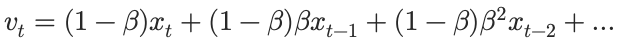

可以看到：
* 越新的数据权重越大
* 越旧的数据权重指数衰减

因此叫：
* 指数加权平均

比如之前的例子：

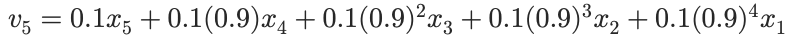

可以看到：
* x₅ 权重最大
* x₄ 次之
* x₃ 更小

也就是说：
* 越新的数据权重越大
* 越旧的数据权重指数衰减

这就是 指数移动加权平均（Exponential Moving Average） 的核心思想。

#### 5. EMA 在优化算法中的作用
在神经网络训练中，EMA 通常用来对 梯度进行平滑处理。

例如：

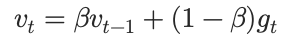

其中：

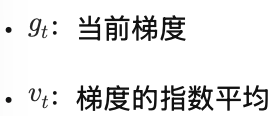

含义是：
* 使用多个历史梯度
* 得到一个更稳定的梯度方向

##### ⚠️注意：
```
这里的每一次的梯度表示同一层的各个参数的梯度在每一个次 batch 训练之后的梯度
而不是表示同一个 batch 中的每一层的各个参数的梯度
```
1. 每一个 batch 会计算一次梯度
2. 这个梯度包含 所有参数的梯度
3. Momentum 会 对每一个参数的梯度序列做 EMA

这里的：

`g_t`

其实是：

`当前 batch 的梯度`

所以：
```
g1 = 第1个batch得到的梯度
g2 = 第2个batch得到的梯度
g3 = 第3个batch得到的梯度
```

##### 5.1 示例：
假设每一batch的梯度为：

这只是一个 简化示例。

真实神经网络中：每一层的梯度不是一个数。

而是：矩阵 / 向量
```
g1 = 5
g2 = -3
g3 = 6
g4 = -2
```
假设：

`β = 0.9`

初始化：

`v₀ = 0`

**第1步** 
```
v₁ = 0.9 × 0 + 0.1 × 5
    = 0.5
```
**第2步**
```
v₂ = 0.9 × 0.5 + 0.1 × (-3)
    = 0.45 - 0.3
    = 0.15
```
**第3步**
```
v₃ = 0.9 × 0.15 + 0.1 × 6
    = 0.135 + 0.6
    = 0.735
```
**第4步**
```
v₄ = 0.9 × 0.735 + 0.1 × (-2)
    = 0.6615 - 0.2
    = 0.4615
```
**结果对比**

原始梯度：

`5,  -3,  6,  -2`

EMA 后的梯度：

`0.5,  0.15,  0.735,  0.4615`

可以看到：
* EMA 的变化更加平滑
* 不会出现剧烈震荡

也就是说：
* EMA 相当于对梯度做了“平滑处理”

从而得到：
* 更稳定的更新方向

##### 5.2 神经网络中的真实情况
假设：

`W1 是 100×50 矩阵`

那么 Momentum 会维护：

`v_W1 (100×50)`

更新公式：

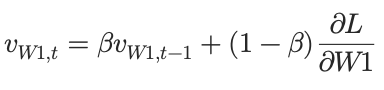
￼
然后更新参数：

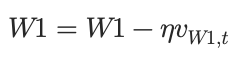
￼
同样：
```
W2 也有自己的 v_W2
b1 也有自己的 v_b1
b2 也有自己的 v_b2
```
所以实际上：
* 每个参数都有自己的 Momentum

#### 6. EMA 与后续优化算法的关系
EMA 是很多优化算法的核心组件。
```
算法	EMA用途
Momentum	对梯度做 EMA
RMSProp	对梯度平方做 EMA
Adam	同时对梯度和梯度平方做 EMA
```
因此 EMA 是这些算法的基础。